In [2]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
cleaned_df = pd.read_csv("Data/cleaned_df.csv")
cleaned_df["Date"] = pd.to_datetime(cleaned_df["Date"])

In [3]:
# Creating predictive df with next 12 months included 
import numpy as np

monthly_dates = pd.date_range(start=np.datetime64('2025-04-01'), end = '2027-03-01', freq = 'MS')
new_data = pd.DataFrame({
    'Date': monthly_dates,
    'Daily_Arrivals': [0] * 24,
    'Year': monthly_dates.year,
    'Daily_Arrivals': cleaned_df["Daily_Arrivals"].iloc[-1]
})

df_naive = pd.concat([cleaned_df, new_data], ignore_index=True)

In [4]:
new_data = pd.DataFrame({
    'Date': monthly_dates,
    'Daily_Arrivals': [0] * 24,
    'Year': monthly_dates.year,
    'Daily_Arrivals': cleaned_df["Daily_Arrivals"].iloc[-12:,].tolist() * 2
})

df_seasonal_naive = pd.concat([cleaned_df, new_data], ignore_index=True)

In [5]:
# Box-Cox Transforming Naive Data
def box_cox (df, lambo):
    if lambo == 0:
        df["Daily_Arrivals_Cox"] = np.log(df["Daily_Arrivals"])
        return df
    else:
        df["Daily_Arrivals_Cox"] = (df["Daily_Arrivals"]**lambo - 1)/lambo
        return df

/var/folders/58/r3zgxt3d0g361_lmqmt90gfh0000gn/T/ipykernel_1436/3266072368.py:11: UserWarning: FixedFormatter should only be used together with FixedLocator
  plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])


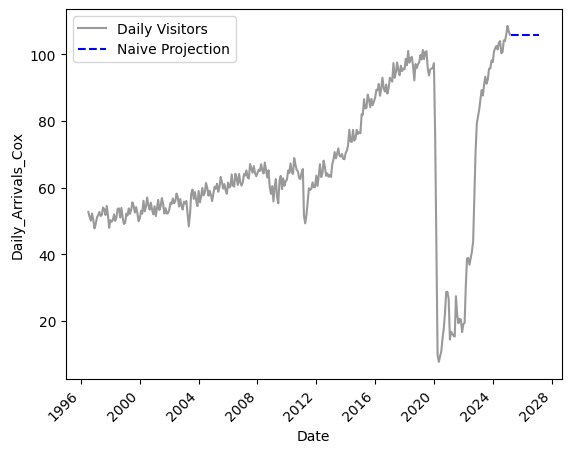

In [6]:
# Simple Graph

def standard_graph(df, column):
    sns.lineplot(data = df.iloc[:-24,:], x = "Date", y = column, 
             alpha = 0.8, 
             color = "Gray", label = "Daily Visitors")
    sns.lineplot(data = df.iloc[-24:, :], x = "Date", y = column, 
             alpha = 1, 
             color = "blue",linestyle = "--", label = "Naive Projection")
    current_values = plt.gca().get_yticks()
    plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])
    plt.xticks(rotation=45, ha="right")

log_df_naive = box_cox(df_naive, lambo = 0.3) # edit the lambo parameter to test out different lambdas
standard_graph(log_df_naive, "Daily_Arrivals_Cox")


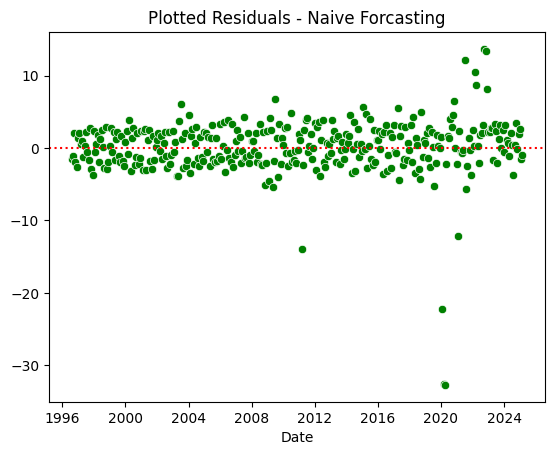

In [7]:
# Testing Residuals for the naive method
log_df_naive2 = log_df_naive.iloc[:-24,:]
y_hat = log_df_naive2["Daily_Arrivals_Cox"].to_numpy()[0:-1]
y = log_df_naive2["Daily_Arrivals_Cox"].to_numpy()[1:]
resid = y - y_hat
sns.scatterplot(x = log_df_naive2["Date"][1:], y = resid, color = "g")
plt.title(label = "Plotted Residuals - Naive Forcasting")
plt.axhline(y = 0, color='red', linestyle=':') 
plt.show()


Nice, let's use computer software to find the optimal lambda

In [8]:
from scipy import stats
placeholder, best_lambda = stats.boxcox(cleaned_df["Daily_Arrivals"])
print(best_lambda)

0.3289945212106721


After setting the lambda to 0.3, this works a lot better

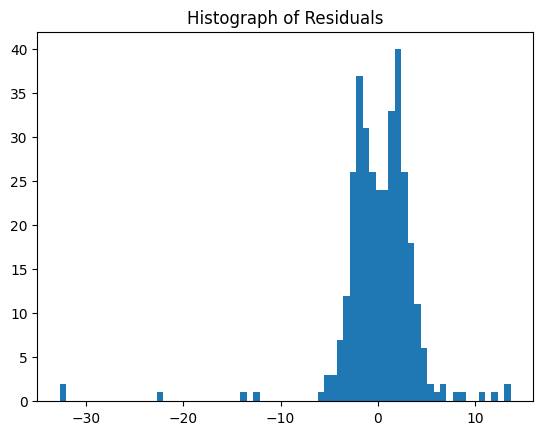

In [9]:
plt.hist(x = resid, bins = 70)
plt.title(label = "Histograph of Residuals")
plt.show()

Some weird bimodal stuff going on here, probably because the shifting month means the naive method is either higher or lower than the previous estimate

Looks pretty, good, maybe a bit too lage of a tail to the left (however, it somehow balances out the stuff on the right)

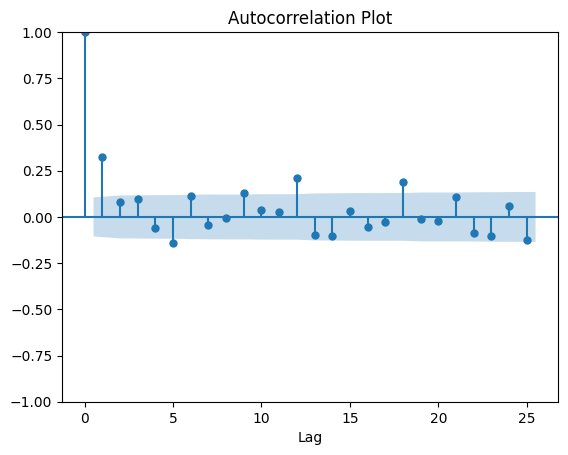

In [10]:
from statsmodels.graphics.tsaplots import plot_acf

# 'data' should be a 1D array or pandas Series
plot_acf(resid, lags = 25)
plt.title(label = "Autocorrelation Plot")
plt.xlabel(xlabel = "Lag")
plt.show()

In [18]:
# Let's find the prediction for next month
log_df_naive.iloc[-27:-22]

,Unnamed: 0,Month,Grand Total,Year,Date,Days,Daily_Arrivals,Daily_Arrivals_Moving_Avg,detrended_x,Month_num,seasonal_component,remainder,Daily_Arrivals_Cox
342,342.0,Jan,3781200.0,2025,2025-01-01,31.0,121974.193548,111483.848214,1.094097,1.0,1.034132,1.314934e+10,108.548386
343,343.0,Feb,3258491.0,2025,2025-02-01,28.0,116374.678571,112342.900634,1.035888,2.0,0.968313,1.350170e+10,106.982105
344,344.0,Mar,3497600.0,2025,2025-03-01,31.0,112825.806452,113555.368062,0.993575,3.0,0.950288,1.348220e+10,105.961915
345,NaN,NaN,NaN,2025,2025-04-01,NaN,112825.806452,NaN,NaN,NaN,NaN,NaN,105.961915
346,NaN,NaN,NaN,2025,2025-05-01,NaN,112825.806452,NaN,NaN,NaN,NaN,NaN,105.961915


The (transformed) prediction for April 2025 is 105.961915

Looks pretty good, outside of first part (correlation of residual with itself), the autocorrelation appears to be pretty random
## Next Step: Calculating Standard Deviation of residuals
We now want to calcualte the standard deviation of the residuals

$\hat{\sigma} = \sqrt{\frac{1}{T-K-M}\sum{e_t^2}}$

Where T is number of times, K is number of parameters estimated in the forecasting method, and M is the number of missing values in the residuals (M = 1 for naive forecast because we don't forecast first observation)

"If a transformation has been used, then the prediction interval is first computed on the transformed scale, and the end points are back-transformed to give a prediction interval on the original scale. This approach preserves the probability coverage of the prediction interval, although it will no longer be symmetric around the point forecast."

In [3]:
std = np.sqrt((1/343)* np.sum(np.square(resid)))
std

NameError: name 'np' is not defined

In [2]:
# Prediction interval
range = std*1.96
lower, upper = 105.961915 - range, 105.961915 + range

NameError: name 'std' is not defined

In [15]:
def unbox(val):
    return (val * 0.3 + 1) ** (1/.3)

lower_untransform, upper_untransform = unbox(lower), unbox(upper)
print("95% confidence interval (For April 2025)")
print((lower_untransform, upper_untransform))
median = unbox(105.961915)
print(median)

95% confidence interval (For April 2025)
(103727.0029955312, 122469.1123577652)
112825.80816197036
